In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [3]:
df = pd.read_csv(r"Hospital Clinical Deterioration.csv")
df

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type,deterioration_next_12h
0,0,68.58,14.47,96.52,37.18,108.94,78.43,none,0.0,2,...,1.28,1.27,10.66,13.55,0.2621,24,M,2,Elective,0
1,1,67.03,13.87,94.94,37.25,111.73,79.14,none,0.0,3,...,1.18,1.22,11.94,13.65,0.3353,24,M,2,Elective,0
2,2,69.05,14.63,94.45,37.29,111.48,78.86,none,0.0,2,...,1.21,1.25,10.24,13.69,0.1678,24,M,2,Elective,0
3,3,69.07,14.42,95.16,37.27,110.68,76.79,none,0.0,2,...,1.13,1.24,10.72,13.61,0.1961,24,M,2,Elective,0
4,4,73.35,15.62,95.83,37.21,110.38,75.47,none,0.0,3,...,1.20,1.21,11.46,13.49,0.3000,24,M,2,Elective,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417861,24,89.82,20.65,95.46,36.43,122.05,70.56,none,0.0,4,...,1.83,1.36,14.76,13.38,0.3906,62,F,1,ED,0
417862,25,92.38,20.80,95.30,36.46,124.08,72.08,none,0.0,1,...,1.71,1.35,14.75,13.29,0.4531,62,F,1,ED,0
417863,26,94.65,21.43,94.39,36.43,123.59,71.41,none,0.0,1,...,1.75,1.40,12.76,13.16,0.1993,62,F,1,ED,0
417864,27,95.72,21.23,94.90,36.46,121.17,70.60,none,0.0,3,...,1.64,1.39,14.96,13.14,0.5195,62,F,1,ED,0


In [4]:
df.columns

Index(['hour_from_admission', 'heart_rate', 'respiratory_rate', 'spo2_pct',
       'temperature_c', 'systolic_bp', 'diastolic_bp', 'oxygen_device',
       'oxygen_flow', 'mobility_score', 'nurse_alert', 'wbc_count', 'lactate',
       'creatinine', 'crp_level', 'hemoglobin', 'sepsis_risk_score', 'age',
       'gender', 'comorbidity_index', 'admission_type',
       'deterioration_next_12h'],
      dtype='str')

In [5]:
df.isnull().sum()

hour_from_admission       0
heart_rate                0
respiratory_rate          0
spo2_pct                  0
temperature_c             0
systolic_bp               0
diastolic_bp              0
oxygen_device             0
oxygen_flow               0
mobility_score            0
nurse_alert               0
wbc_count                 0
lactate                   0
creatinine                0
crp_level                 0
hemoglobin                0
sepsis_risk_score         0
age                       0
gender                    0
comorbidity_index         0
admission_type            0
deterioration_next_12h    0
dtype: int64

In [6]:
df.describe()

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_flow,mobility_score,nurse_alert,wbc_count,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,comorbidity_index,deterioration_next_12h
count,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000,417866.000000
mean,24.098240,89.258118,20.177237,93.504918,36.968563,113.398465,70.516530,7.967031,2.283012,0.221243,9.198275,1.987468,1.318961,34.232249,13.279612,0.493449,53.863521,4.001931,0.054058
std,16.935515,21.127257,6.849362,5.950330,0.451594,17.107426,10.670383,16.248186,0.925933,0.415084,4.076129,1.511936,0.669615,36.282849,1.160177,0.222574,20.947460,2.602512,0.226132
min,0.000000,40.000000,8.000000,70.000000,35.240000,70.000000,40.000000,0.000000,0.000000,0.000000,2.000000,0.500000,0.400000,0.000000,7.000000,0.017600,18.000000,0.000000,0.000000
25%,10.000000,76.920000,15.860000,92.510000,36.700000,103.980000,65.020000,0.000000,2.000000,0.000000,7.000000,1.250000,0.970000,15.660000,12.680000,0.325500,36.000000,2.000000,0.000000
50%,21.000000,86.330000,19.330000,94.830000,36.920000,114.830000,71.470000,0.000000,2.000000,0.000000,8.490000,1.610000,1.190000,26.630000,13.360000,0.465850,54.000000,4.000000,0.000000
75%,36.000000,96.860000,23.040000,96.850000,37.150000,124.850000,77.440000,0.700000,3.000000,0.000000,10.160000,2.030000,1.430000,38.670000,14.020000,0.628400,72.000000,6.000000,0.000000
max,71.000000,180.000000,45.000000,100.000000,40.500000,184.560000,110.000000,56.190000,4.000000,1.000000,30.000000,8.000000,4.500000,250.000000,17.000000,0.999900,90.000000,8.000000,1.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 417866 entries, 0 to 417865
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   hour_from_admission     417866 non-null  int64  
 1   heart_rate              417866 non-null  float64
 2   respiratory_rate        417866 non-null  float64
 3   spo2_pct                417866 non-null  float64
 4   temperature_c           417866 non-null  float64
 5   systolic_bp             417866 non-null  float64
 6   diastolic_bp            417866 non-null  float64
 7   oxygen_device           417866 non-null  str    
 8   oxygen_flow             417866 non-null  float64
 9   mobility_score          417866 non-null  int64  
 10  nurse_alert             417866 non-null  int64  
 11  wbc_count               417866 non-null  float64
 12  lactate                 417866 non-null  float64
 13  creatinine              417866 non-null  float64
 14  crp_level               417866 

In [8]:
df.head()

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type,deterioration_next_12h
0,0,68.58,14.47,96.52,37.18,108.94,78.43,none,0.0,2,...,1.28,1.27,10.66,13.55,0.2621,24,M,2,Elective,0
1,1,67.03,13.87,94.94,37.25,111.73,79.14,none,0.0,3,...,1.18,1.22,11.94,13.65,0.3353,24,M,2,Elective,0
2,2,69.05,14.63,94.45,37.29,111.48,78.86,none,0.0,2,...,1.21,1.25,10.24,13.69,0.1678,24,M,2,Elective,0
3,3,69.07,14.42,95.16,37.27,110.68,76.79,none,0.0,2,...,1.13,1.24,10.72,13.61,0.1961,24,M,2,Elective,0
4,4,73.35,15.62,95.83,37.21,110.38,75.47,none,0.0,3,...,1.20,1.21,11.46,13.49,0.3000,24,M,2,Elective,0


In [9]:
df.tail()

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type,deterioration_next_12h
417861,24,89.82,20.65,95.46,36.43,122.05,70.56,none,0.0,4,...,1.83,1.36,14.76,13.38,0.3906,62,F,1,ED,0
417862,25,92.38,20.80,95.30,36.46,124.08,72.08,none,0.0,1,...,1.71,1.35,14.75,13.29,0.4531,62,F,1,ED,0
417863,26,94.65,21.43,94.39,36.43,123.59,71.41,none,0.0,1,...,1.75,1.40,12.76,13.16,0.1993,62,F,1,ED,0
417864,27,95.72,21.23,94.90,36.46,121.17,70.60,none,0.0,3,...,1.64,1.39,14.96,13.14,0.5195,62,F,1,ED,0
417865,28,93.46,20.76,94.83,36.42,119.53,71.02,none,0.0,2,...,1.59,1.37,12.98,13.09,0.5923,62,F,1,ED,0


In [10]:
df.deterioration_next_12h.unique()

array([0, 1], dtype=int64)

In [11]:
df['deterioration_next_12h'].value_counts()

deterioration_next_12h
0    395277
1     22589
Name: count, dtype: int64

In [12]:
df.select_dtypes(include='object').columns

Index(['oxygen_device', 'gender', 'admission_type'], dtype='str')

In [13]:
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

In [14]:
X = df_encoded.drop(columns=['deterioration_next_12h'])
y = df_encoded['deterioration_next_12h']


In [15]:
X = df_encoded.drop(columns=['deterioration_next_12h'])
y = df_encoded['deterioration_next_12h']


In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

In [17]:
y_balanced.value_counts()


deterioration_next_12h
0    395277
1    395277
Name: count, dtype: int64

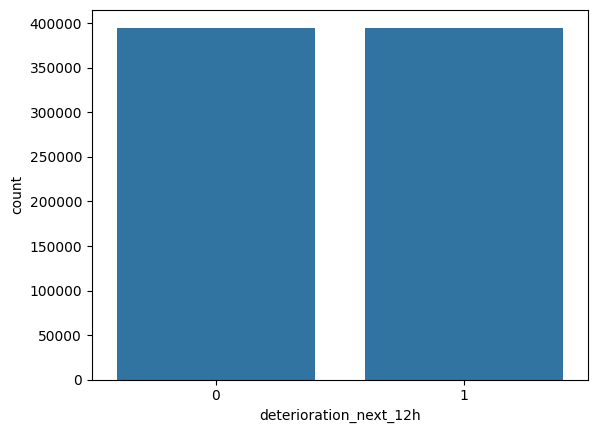

In [18]:
sns.countplot(x=y_balanced)
plt.show()

In [19]:
numeric_df = df_encoded.select_dtypes(include='number')


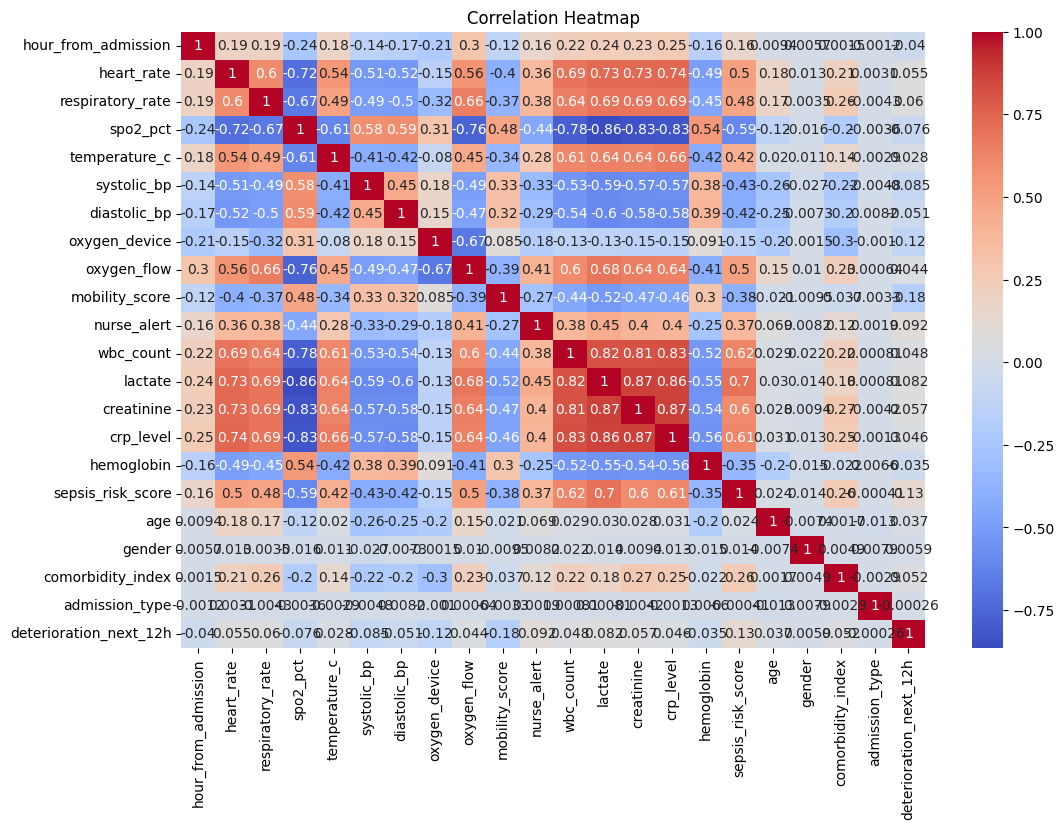

In [20]:
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [21]:
df.deterioration_next_12h.unique()

array([0, 1], dtype=int64)

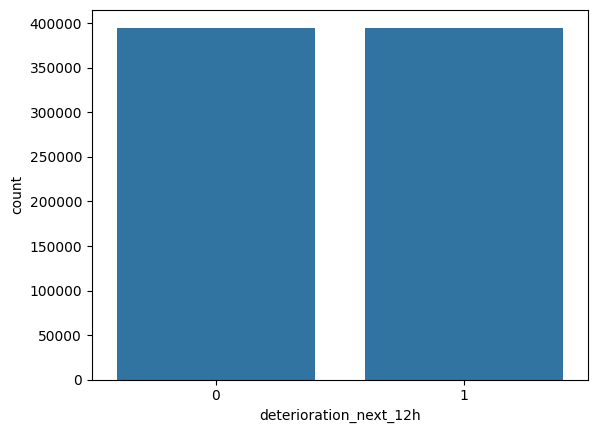

In [22]:
sns.countplot(x=y_balanced)
plt.show()

In [23]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) 

In [24]:
x_train.shape

(334292, 21)

In [25]:
x_test.shape

(83574, 21)

In [26]:
y_train.shape

(334292,)

In [27]:
y_test.shape

(83574,)

In [28]:
#defining global variables to store accuracy and other metrics
precision = []
recall = []
fscore = []
accuracy = []
labels = ['No Deterioration', 'Deterioration']

In [29]:
def calculateMetrics(algorithm, predict, testY):
    testY = testY.astype(int)
    predict = predict.astype(int)

    a = accuracy_score(testY, predict)
    p = precision_score(testY, predict)
    r = recall_score(testY, predict)
    f = f1_score(testY, predict)

    print(f"{algorithm} Accuracy  :", a)
    print(f"{algorithm} Precision :", p)
    print(f"{algorithm} Recall    :", r)
    print(f"{algorithm} F1-Score  :", f)

    labels = ['No Deterioration', 'Deterioration']
    print("\nClassification Report:\n")
    print(classification_report(testY, predict, target_names=labels))

    cm = confusion_matrix(testY, predict)
    print("Confusion Matrix:\n", cm)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{algorithm} Confusion Matrix")
    plt.show()


Isolation Forest Accuracy  : 0.894943403450834
Isolation Forest Precision : 0.0018899125915426411
Isolation Forest Recall    : 0.0017532325224632918
Isolation Forest F1-Score  : 0.0018190086402910413

Classification Report:

                  precision    recall  f1-score   support

No Deterioration       0.94      0.95      0.94     79011
   Deterioration       0.00      0.00      0.00      4563

        accuracy                           0.89     83574
       macro avg       0.47      0.47      0.47     83574
    weighted avg       0.89      0.89      0.89     83574

Confusion Matrix:
 [[74786  4225]
 [ 4555     8]]


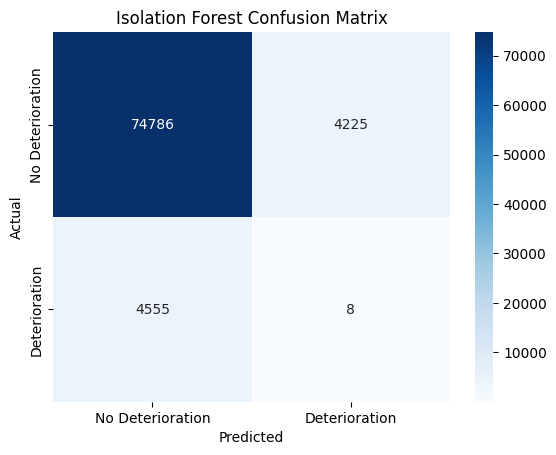

['IsolationForest_weights.pkl']

In [30]:
from sklearn.ensemble import IsolationForest
import numpy as np
import joblib

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

iso_forest.fit(x_train)

iso_pred = iso_forest.predict(x_test)
iso_pred = np.where(iso_pred == -1, 1, 0)

calculateMetrics("Isolation Forest", iso_pred, y_test)

joblib.dump(iso_forest, "IsolationForest_weights.pkl")


Bayesian Ridge Accuracy  : 0.9454016799483093
Bayesian Ridge Precision : 0.0
Bayesian Ridge Recall    : 0.0
Bayesian Ridge F1-Score  : 0.0

Classification Report:

                  precision    recall  f1-score   support

No Deterioration       0.95      1.00      0.97     79011
   Deterioration       0.00      0.00      0.00      4563

        accuracy                           0.95     83574
       macro avg       0.47      0.50      0.49     83574
    weighted avg       0.89      0.95      0.92     83574

Confusion Matrix:
 [[79011     0]
 [ 4563     0]]


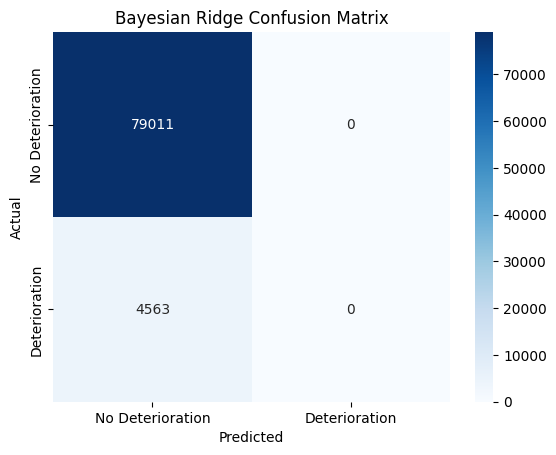

['BayesianRidge_weights.pkl']

In [31]:
from sklearn.linear_model import BayesianRidge
import numpy as np
import joblib

bayes_ridge = BayesianRidge()
bayes_ridge.fit(x_train, y_train)

y_pred_continuous = bayes_ridge.predict(x_test)
y_pred_bayes = (y_pred_continuous >= 0.5).astype(int)

calculateMetrics("Bayesian Ridge", y_pred_bayes, y_test)

joblib.dump(bayes_ridge, "BayesianRidge_weights.pkl")


Logistic Regression Accuracy  : 0.7491564362122191
Logistic Regression Precision : 0.14132003674058521
Logistic Regression Recall    : 0.7080867850098619
Logistic Regression F1-Score  : 0.23561583898490485

Classification Report:

                  precision    recall  f1-score   support

No Deterioration       0.98      0.75      0.85     79011
   Deterioration       0.14      0.71      0.24      4563

        accuracy                           0.75     83574
       macro avg       0.56      0.73      0.54     83574
    weighted avg       0.93      0.75      0.82     83574

Confusion Matrix:
 [[59379 19632]
 [ 1332  3231]]


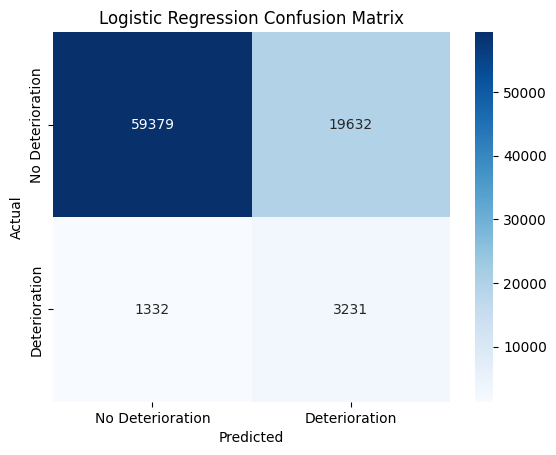

['LogisticRegression_weights.pkl']

In [32]:
from sklearn.linear_model import LogisticRegression
import joblib

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_reg.fit(x_train, y_train)

log_pred = log_reg.predict(x_test)

calculateMetrics("Logistic Regression", log_pred, y_test)

joblib.dump(log_reg, "LogisticRegression_weights.pkl")


In [33]:
from sklearn.ensemble import GradientBoostingClassifier


Gradient Boosting Accuracy  : 0.9602029339268193
Gradient Boosting Precision : 0.7835855112333792
Gradient Boosting Recall    : 0.3745342976112207
Gradient Boosting F1-Score  : 0.5068208778173191

Classification Report:

                  precision    recall  f1-score   support

No Deterioration       0.96      0.99      0.98     79011
   Deterioration       0.78      0.37      0.51      4563

        accuracy                           0.96     83574
       macro avg       0.87      0.68      0.74     83574
    weighted avg       0.96      0.96      0.95     83574

Confusion Matrix:
 [[78539   472]
 [ 2854  1709]]


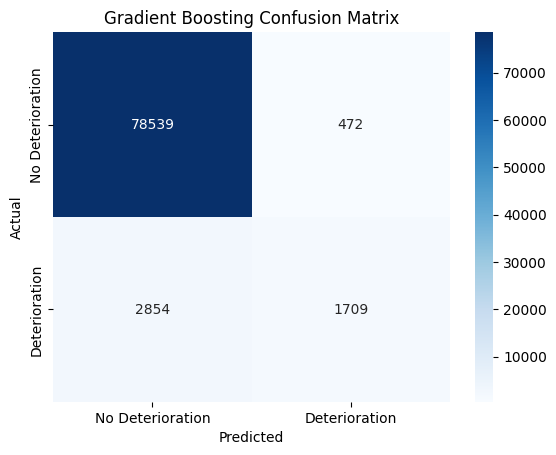

['GradientBoosting_weights.pkl']

In [34]:

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(x_train, y_train)
gb_pred = gb.predict(x_test)

calculateMetrics("Gradient Boosting", gb_pred, y_test)
joblib.dump(gb, "GradientBoosting_weights.pkl")


In [35]:

testdata = pd.read_csv(r"test1.csv")
testdata

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,wbc_count,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type
0,50,143.91,44.83,77.95,38.03,82.82,52.70,niv,50.78,1,...,17.02,5.83,2.52,103.26,11.01,0.9652,86,F,5,ED
1,31,116.94,16.18,91.42,36.08,123.96,65.66,nasal,3.04,4,...,7.04,1.71,1.82,29.14,13.87,0.2460,88,M,7,ED
2,28,94.61,23.56,95.29,36.34,102.87,87.85,none,0.00,2,...,5.74,1.67,1.45,39.87,12.29,0.4610,26,M,7,ED
3,65,70.00,19.91,98.44,37.38,110.08,80.20,none,0.00,2,...,7.46,2.07,1.24,4.69,12.80,0.4382,27,F,0,ED
4,0,94.87,18.81,96.21,37.02,127.35,82.49,none,0.00,3,...,5.44,1.37,1.29,20.18,14.14,0.3093,27,F,2,ED
5,61,63.89,10.02,95.20,36.23,136.93,78.04,none,0.00,2,...,5.26,1.11,1.28,32.62,14.80,0.6737,45,M,2,ED
6,4,69.95,13.18,93.08,37.18,143.37,63.22,none,0.00,3,...,12.42,2.03,1.86,47.03,13.73,0.6274,31,M,8,ED
7,17,101.31,21.52,98.49,36.86,114.66,60.45,none,0.00,2,...,7.88,1.59,0.87,19.79,12.48,0.1519,90,M,3,ED
8,65,84.71,8.09,92.65,37.07,104.82,79.09,none,0.00,3,...,9.38,2.62,0.55,5.07,13.49,0.5879,39,F,5,ED
9,37,96.57,18.64,99.42,36.47,116.46,71.17,none,0.00,3,...,11.34,2.03,1.46,60.45,12.85,0.6757,71,M,5,Elective


In [36]:
testdata.columns

Index(['hour_from_admission', 'heart_rate', 'respiratory_rate', 'spo2_pct',
       'temperature_c', 'systolic_bp', 'diastolic_bp', 'oxygen_device',
       'oxygen_flow', 'mobility_score', 'nurse_alert', 'wbc_count', 'lactate',
       'creatinine', 'crp_level', 'hemoglobin', 'sepsis_risk_score', 'age',
       'gender', 'comorbidity_index', 'admission_type'],
      dtype='str')

In [37]:
testdata.isnull().sum()


hour_from_admission    0
heart_rate             0
respiratory_rate       0
spo2_pct               0
temperature_c          0
systolic_bp            0
diastolic_bp           0
oxygen_device          0
oxygen_flow            0
mobility_score         0
nurse_alert            0
wbc_count              0
lactate                0
creatinine             0
crp_level              0
hemoglobin             0
sepsis_risk_score      0
age                    0
gender                 0
comorbidity_index      0
admission_type         0
dtype: int64

In [38]:
testdata.describe()

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_flow,mobility_score,nurse_alert,wbc_count,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,comorbidity_index
count,20.000000,20.0000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,31.200000,96.5790,20.111000,93.563000,36.856500,116.051000,72.903000,5.001500,2.100000,0.150000,9.060500,2.230000,1.427500,40.568000,12.905500,0.492880,50.250000,3.650000
std,22.272475,28.4488,9.483332,7.228523,0.533817,17.737875,12.614884,14.908341,0.967906,0.366348,4.986618,1.697943,0.846179,44.808743,1.155297,0.243176,23.856755,2.641272
min,0.000000,61.2100,8.090000,70.000000,36.080000,70.000000,40.000000,0.000000,0.000000,0.000000,3.880000,0.680000,0.460000,4.690000,9.950000,0.131500,23.000000,0.000000
25%,11.500000,79.9050,16.187500,92.972500,36.522500,108.765000,65.092500,0.000000,2.000000,0.000000,5.912500,1.427500,1.080000,17.017500,12.480000,0.266250,30.000000,1.750000
50%,29.500000,92.9450,19.490000,95.695000,36.790000,119.510000,75.785000,0.000000,2.000000,0.000000,7.890000,1.785000,1.285000,33.250000,13.015000,0.527650,43.000000,3.000000
75%,50.000000,103.0775,20.472500,97.115000,37.032500,128.000000,80.610000,0.000000,3.000000,0.000000,9.492500,2.102500,1.465000,41.640000,13.737500,0.607975,71.500000,5.250000
max,65.000000,177.9800,45.000000,100.000000,38.140000,143.370000,91.940000,50.780000,4.000000,1.000000,26.050000,8.000000,4.430000,203.950000,14.800000,0.998800,90.000000,8.000000


In [39]:
testdata.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   hour_from_admission  20 non-null     int64  
 1   heart_rate           20 non-null     float64
 2   respiratory_rate     20 non-null     float64
 3   spo2_pct             20 non-null     float64
 4   temperature_c        20 non-null     float64
 5   systolic_bp          20 non-null     float64
 6   diastolic_bp         20 non-null     float64
 7   oxygen_device        20 non-null     str    
 8   oxygen_flow          20 non-null     float64
 9   mobility_score       20 non-null     int64  
 10  nurse_alert          20 non-null     int64  
 11  wbc_count            20 non-null     float64
 12  lactate              20 non-null     float64
 13  creatinine           20 non-null     float64
 14  crp_level            20 non-null     float64
 15  hemoglobin           20 non-null     float64
 16  sep

In [40]:
testdata.head()

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,wbc_count,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type
0,50,143.91,44.83,77.95,38.03,82.82,52.70,niv,50.78,1,...,17.02,5.83,2.52,103.26,11.01,0.9652,86,F,5,ED
1,31,116.94,16.18,91.42,36.08,123.96,65.66,nasal,3.04,4,...,7.04,1.71,1.82,29.14,13.87,0.2460,88,M,7,ED
2,28,94.61,23.56,95.29,36.34,102.87,87.85,none,0.00,2,...,5.74,1.67,1.45,39.87,12.29,0.4610,26,M,7,ED
3,65,70.00,19.91,98.44,37.38,110.08,80.20,none,0.00,2,...,7.46,2.07,1.24,4.69,12.80,0.4382,27,F,0,ED
4,0,94.87,18.81,96.21,37.02,127.35,82.49,none,0.00,3,...,5.44,1.37,1.29,20.18,14.14,0.3093,27,F,2,ED


In [41]:
testdata.tail()

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,wbc_count,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type
15,46,108.38,16.19,100.00,36.65,122.56,81.84,none,0.00,0,...,5.17,1.44,1.36,40.16,12.98,0.5950,57,M,2,ED
16,50,78.00,9.23,92.34,36.87,130.73,63.39,none,0.00,3,...,3.88,0.68,0.87,16.20,12.48,0.2403,25,F,1,ED
17,12,80.54,20.08,96.99,36.72,123.94,76.70,none,0.00,2,...,5.97,1.69,1.20,17.29,14.09,0.5323,84,M,3,ED
18,42,177.98,45.00,70.00,38.14,70.00,40.00,niv,46.21,0,...,26.05,8.00,4.43,203.95,9.95,0.9988,43,F,2,ED
19,0,87.17,19.07,96.10,36.95,101.47,91.94,none,0.00,2,...,8.60,1.86,1.20,38.60,13.12,0.2730,35,F,5,Transfer


In [42]:
testdata.select_dtypes(include='object').columns

Index(['oxygen_device', 'gender', 'admission_type'], dtype='str')

In [43]:
testdata_encoded = testdata.copy()

for col in testdata_encoded.select_dtypes(include='object').columns:
    testdata_encoded[col] = LabelEncoder().fit_transform(testdata_encoded[col])

In [44]:
# Create clean test data
testdata_clean = testdata.copy()


In [45]:
testdata_clean.columns


Index(['hour_from_admission', 'heart_rate', 'respiratory_rate', 'spo2_pct',
       'temperature_c', 'systolic_bp', 'diastolic_bp', 'oxygen_device',
       'oxygen_flow', 'mobility_score', 'nurse_alert', 'wbc_count', 'lactate',
       'creatinine', 'crp_level', 'hemoglobin', 'sepsis_risk_score', 'age',
       'gender', 'comorbidity_index', 'admission_type'],
      dtype='str')

In [62]:
for col in ['oxygen_device', 'gender', 'admission_type']:
    print(col, testdata_clean[col].unique())


oxygen_device [0]
gender [0]
admission_type [0]


In [63]:
# FINAL FIX: convert categorical columns directly to numeric

testdata_clean['oxygen_device'] = 0
testdata_clean['gender'] = 0
testdata_clean['admission_type'] = 0



In [1]:
testdata_clean.dtypes


NameError: name 'testdata_clean' is not defined

In [65]:
# Step 3: Align test data column order with training data
testdata_final = testdata_clean[X.columns]


In [66]:
print(list(testdata_final.columns) == list(X.columns))


True


In [67]:
# Final prediction
predictions = gb.predict(testdata_final)

predictions


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int64)

In [68]:

testdata_final['prediction'] = [labels[i] for i in predictions]
testdata_final

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type,prediction
0,50,143.91,44.83,77.95,38.03,82.82,52.70,0,50.78,1,...,5.83,2.52,103.26,11.01,0.9652,86,0,5,0,No Deterioration
1,31,116.94,16.18,91.42,36.08,123.96,65.66,0,3.04,4,...,1.71,1.82,29.14,13.87,0.2460,88,0,7,0,No Deterioration
2,28,94.61,23.56,95.29,36.34,102.87,87.85,0,0.00,2,...,1.67,1.45,39.87,12.29,0.4610,26,0,7,0,No Deterioration
3,65,70.00,19.91,98.44,37.38,110.08,80.20,0,0.00,2,...,2.07,1.24,4.69,12.80,0.4382,27,0,0,0,No Deterioration
4,0,94.87,18.81,96.21,37.02,127.35,82.49,0,0.00,3,...,1.37,1.29,20.18,14.14,0.3093,27,0,2,0,No Deterioration
5,61,63.89,10.02,95.20,36.23,136.93,78.04,0,0.00,2,...,1.11,1.28,32.62,14.80,0.6737,45,0,2,0,No Deterioration
6,4,69.95,13.18,93.08,37.18,143.37,63.22,0,0.00,3,...,2.03,1.86,47.03,13.73,0.6274,31,0,8,0,No Deterioration
7,17,101.31,21.52,98.49,36.86,114.66,60.45,0,0.00,2,...,1.59,0.87,19.79,12.48,0.1519,90,0,3,0,No Deterioration
8,65,84.71,8.09,92.65,37.07,104.82,79.09,0,0.00,3,...,2.62,0.55,5.07,13.49,0.5879,39,0,5,0,No Deterioration
9,37,96.57,18.64,99.42,36.47,116.46,71.17,0,0.00,3,...,2.03,1.46,60.45,12.85,0.6757,71,0,5,0,No Deterioration
